In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
df = pd.read_excel(r"C:\Users\sharm\Downloads\employee_attrition_dataset_1000.xlsx")

In [6]:
df.head()

,EmployeeID,Age,Gender,Department,JobRole,MonthlyIncome,YearsAtCompany,DistanceFromHome,MaritalStatus,EducationField,JobSatisfaction,OverTime,Attrition,City,PerformanceRating
0,1,28.0,Male,Marketing,Manager,24556.0,8.0,16.0,Divorced,Human Resources,2.0,Yes,No,Delhi,1.0
1,2,59.0,Male,Finance,Developer,24956.0,17.0,13.0,Married,Life Sciences,4.0,Yes,No,Bangalore,3.0
2,3,42.0,Female,Research & Development,Developer,44793.0,2.0,25.0,Married,Life Sciences,1.0,No,No,Hyderabad,1.0
3,4,25.0,Male,Sales,HR Executive,30012.0,7.0,19.0,Married,Technical Degree,1.0,No,Yes,Bangalore,2.0
4,5,36.0,Male,Marketing,Research Scientist,60834.0,14.0,25.0,Single,Medical,3.0,Yes,No,Hyderabad,3.0


In [25]:
df.shape

(1025, 15)

In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   EmployeeID         1025 non-null   int64  
 1   Age                1013 non-null   float64
 2   Gender             1011 non-null   str    
 3   Department         1019 non-null   str    
 4   JobRole            1013 non-null   str    
 5   MonthlyIncome      1013 non-null   float64
 6   YearsAtCompany     1018 non-null   float64
 7   DistanceFromHome   1012 non-null   float64
 8   MaritalStatus      1019 non-null   str    
 9   EducationField     1022 non-null   str    
 10  JobSatisfaction    1017 non-null   float64
 11  OverTime           1017 non-null   str    
 12  Attrition          999 non-null    str    
 13  City               1008 non-null   str    
 14  PerformanceRating  1014 non-null   float64
dtypes: float64(6), int64(1), str(8)
memory usage: 120.2 KB


In [27]:
df.isnull().sum()

EmployeeID            0
Age                  12
Gender               14
Department            6
JobRole              12
MonthlyIncome        12
YearsAtCompany        7
DistanceFromHome     13
MaritalStatus         6
EducationField        3
JobSatisfaction       8
OverTime              8
Attrition            26
City                 17
PerformanceRating    11
dtype: int64

In [28]:
df.dropna(inplace=True)

In [30]:
df.shape

(875, 15)

In [31]:
total_employees = len(df)

print("Total Employees:", total_employees)

Total Employees: 875


In [32]:
employees_left = df[df["Attrition"] == "Yes"].shape[0]

print("Employees Left:", employees_left)

Employees Left: 193


In [33]:
attrition_rate = (employees_left / total_employees) * 100

print("Attrition Rate:", round(attrition_rate, 2), "%")

Attrition Rate: 22.06 %


In [34]:
avg_age = df[df["Attrition"] == "Yes"]["Age"].mean()

print("Average Age:", round(avg_age, 2))

Average Age: 40.33


In [35]:
attrition_by_dept = df[df["Attrition"] == "Yes"].groupby("Department").size()

print(attrition_by_dept)

Department
Finance                   28
HR                        36
IT                        31
Marketing                 37
Research & Development    25
Sales                     36
dtype: int64


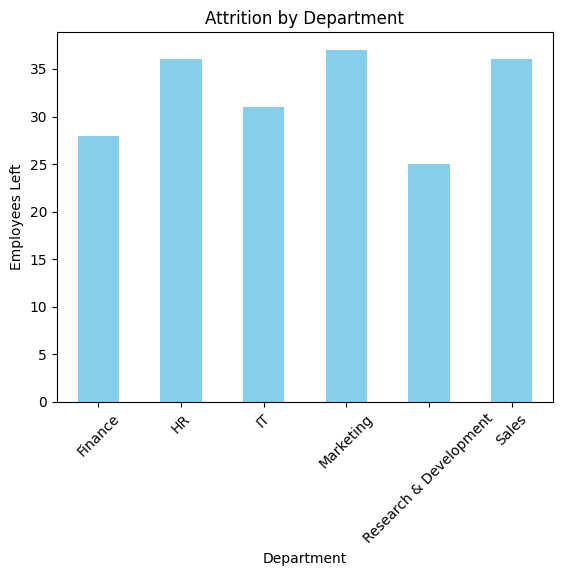

In [36]:
attrition_by_dept.plot(kind="bar", color="skyblue")

plt.title("Attrition by Department")
plt.xlabel("Department")
plt.ylabel("Employees Left")
plt.xticks(rotation=45)

plt.show()

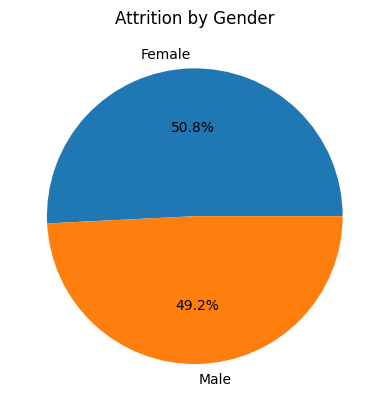

In [37]:
gender_attrition = df[df["Attrition"] == "Yes"].groupby("Gender").size()

gender_attrition.plot(kind="pie", autopct="%1.1f%%")

plt.title("Attrition by Gender")
plt.ylabel("")

plt.show()

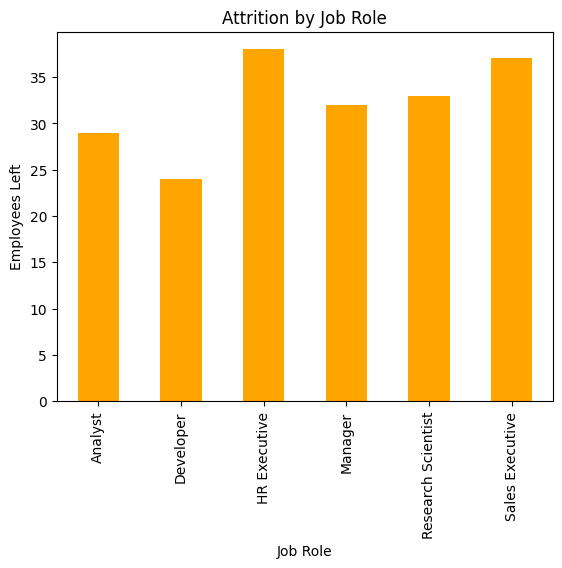

In [38]:
jobrole_attrition = df[df["Attrition"] == "Yes"].groupby("JobRole").size()

jobrole_attrition.plot(kind="bar", color="orange")

plt.title("Attrition by Job Role")
plt.xlabel("Job Role")
plt.ylabel("Employees Left")

plt.xticks(rotation=90)

plt.show()

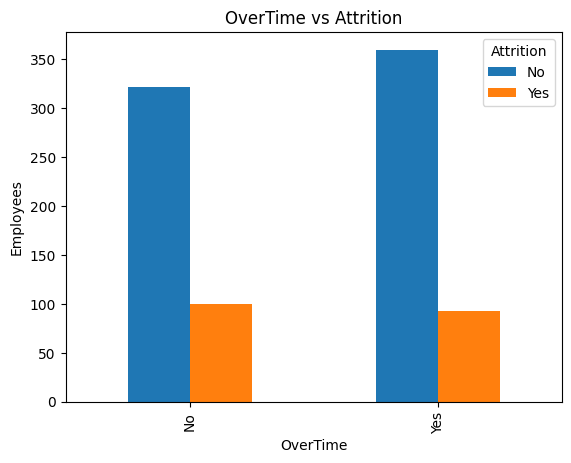

In [39]:
overtime_attrition = pd.crosstab(df["OverTime"], df["Attrition"])

overtime_attrition.plot(kind="bar")

plt.title("OverTime vs Attrition")
plt.xlabel("OverTime")
plt.ylabel("Employees")

plt.show()

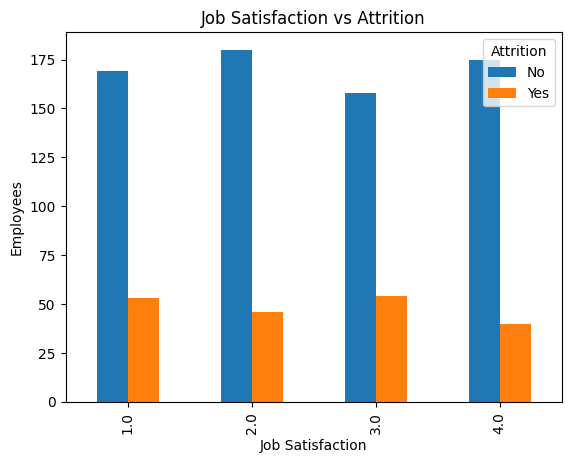

In [40]:
satisfaction_attrition = pd.crosstab(df["JobSatisfaction"], df["Attrition"])

satisfaction_attrition.plot(kind="bar")

plt.title("Job Satisfaction vs Attrition")
plt.xlabel("Job Satisfaction")
plt.ylabel("Employees")

plt.show()

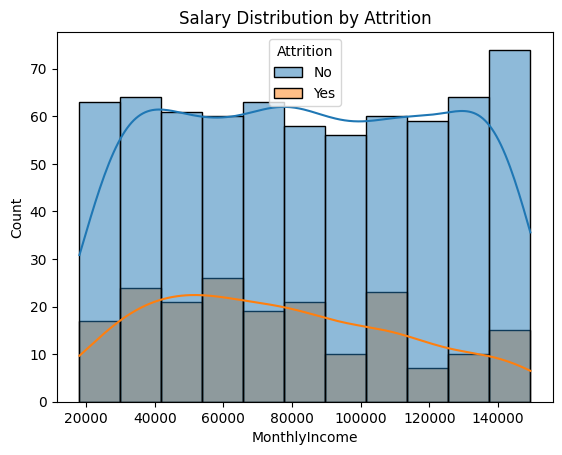

In [41]:
sns.histplot(data=df, x="MonthlyIncome", hue="Attrition", kde=True)

plt.title("Salary Distribution by Attrition")

plt.show()

In [42]:
print("========== HR ATTRITION REPORT ==========")

print("Total Employees:", total_employees)

print("Employees Left:", employees_left)

print("Attrition Rate:", round(attrition_rate,2), "%")

print("Average Age of Employees Leaving:", round(avg_age,2))

========== HR ATTRITION REPORT ==========
Total Employees: 875
Employees Left: 193
Attrition Rate: 22.06 %
Average Age of Employees Leaving: 40.33
